# EDA — Vision Transformers: Patch Tokenization of CIFAR-100

**Purpose**: Understand how a Vision Transformer "sees" CIFAR-100 — as a **sequence of patches**, not a 2D grid. This EDA establishes the mental model shift from CNN (spatial convolutions over a hierarchical feature map) to ViT (attention over a flat sequence of patch tokens + positional embedding).

**Key decisions this EDA informs**:
- Patch size (2, 4, or 8) -> determines sequence length and per-patch information content
- Whether to reuse CNN #11's preprocessing (yes, for direct architecture comparison)
- Visual confirmation that class balance and data integrity match CNN #11 expectations

**Reference model**: CNN #11 (ResNet-20) achieved 80.1% test accuracy (PT) / 79.5% (TF) on this exact dataset. ViT #17 will be benchmarked against that.

[1/3] CIFAR-100 DATA LOAD + INTEGRITY CHECK

Shapes:
    X_train: (50000, 32, 32, 3)    dtype: float32
    X_test:  (10000, 32, 32, 3)    dtype: float32
    y_train_fine: (50000,)    range: [0, 99]
    y_test_fine:  (10000,)    range: [0, 99]
    Normalization: [0,1] (X / 255.0)
    Pixel range: [0.000, 1.000]

Class balance (fine, 100 classes):
    Classes found: 100
    Samples per class:  min=500, max=500, mean=500.0
    Balanced: True

Sampling 1 image from each of 5 random classes...


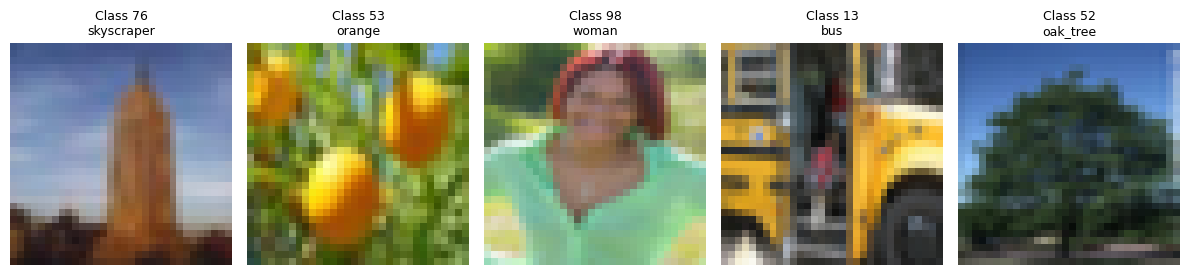

In [1]:
# Step 1: Setup + Class Distribution Sanity Check

# Imports
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Constants
RANDOM_STATE = 113
DATA_DIR = Path('../data/processed/cnn')

np.random.seed(RANDOM_STATE)

# Load CIFAR-100 preprocessed data (reused from CNN #11 pipeline)
print("=" * 60)
print("[1/3] CIFAR-100 DATA LOAD + INTEGRITY CHECK")
print("=" * 60)

X_train = np.load(DATA_DIR / 'X_train.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_train_fine = np.load(DATA_DIR / 'y_train_fine.npy')
y_test_fine = np.load(DATA_DIR / 'y_test_fine.npy')

with open(DATA_DIR / 'preprocessing_info.json') as f:
    info = json.load(f)

fine_class_names = info['fine_class_names']

# Verify shapes + dtype + pixel range match CNN #11 expectations
print(f"\nShapes:")
print(f"    X_train: {X_train.shape}    dtype: {X_train.dtype}")
print(f"    X_test:  {X_test.shape}    dtype: {X_test.dtype}")
print(f"    y_train_fine: {y_train_fine.shape}    range: [{y_train_fine.min()}, {y_train_fine.max()}]")
print(f"    y_test_fine:  {y_test_fine.shape}    range: [{y_test_fine.min()}, {y_test_fine.max()}]")
print(f"    Normalization: {info['normalization']}")
print(f"    Pixel range: [{X_train.min():.3f}, {X_train.max():.3f}]")

# Class balance check (expect 500 samples/class, perfectly balanced)
print(f"\nClass balance (fine, 100 classes):")
unique, counts = np.unique(y_train_fine, return_counts=True)
print(f"    Classes found: {len(unique)}")
print(f"    Samples per class:  min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f}")
print(f"    Balanced: {counts.min() == counts.max()}")

# Display 5 random class samples — confirms image loading + class name alignment
print(f"\nSampling 1 image from each of 5 random classes...")

sample_classes = np.random.choice(100, size=5, replace=False)
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for ax, cls in zip(axes, sample_classes):
    idx = np.where(y_train_fine == cls)[0][0]
    ax.imshow(X_train[idx])
    ax.set_title(f"Class {cls}\n{fine_class_names[cls]}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

[2/3] PATCH DECOMPOSITION — HOW ViT SEES AN IMAGE

Patch configuration:
    Image size:    32 x 32 x 3
    Patch size:    4 x 4
    Patch grid:    8 x 8 = 64 patches
    Per-patch dim: 48 (4*4*3 flattened)


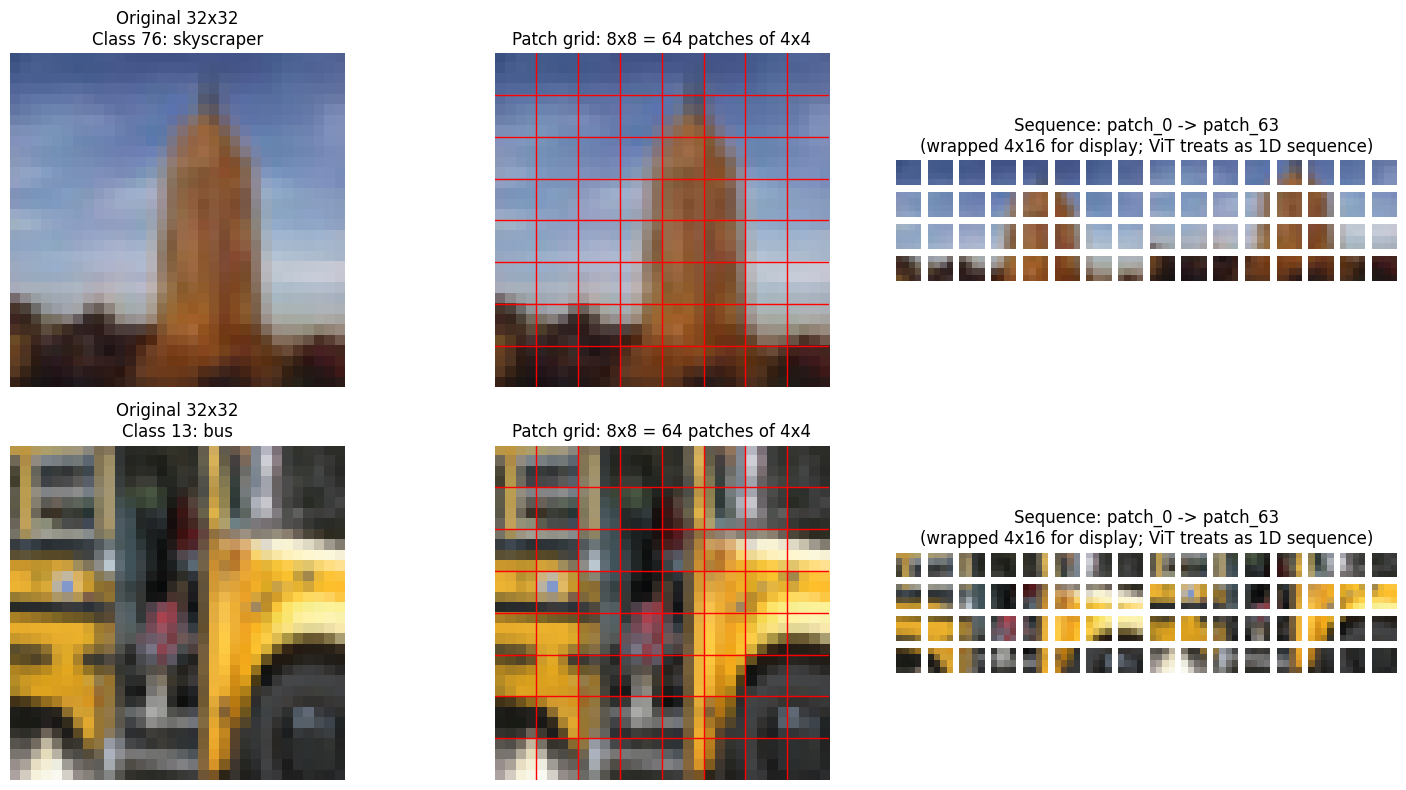


The mental model shift:
    CNN:  (32, 32, 3) image -> spatial convolutions over 2D grid -> feature hierarchy
    ViT:  (32, 32, 3) image -> split into 64 patches -> SEQUENCE -> self-attention

    ViT has NO built-in spatial bias. Position is encoded ONLY via a learnable
    positional embedding added to each patch token. This is why ViT is data-hungry:
    it must LEARN spatial relationships that CNNs get for free.


In [2]:
# Step 2: Patch Decomposition Visualization

# Patch configuration constants
PATCH_SIZE = 4
NUM_PATCHES_H = 32 // PATCH_SIZE   # 8
NUM_PATCHES_W = 32 // PATCH_SIZE   # 8
NUM_PATCHES = NUM_PATCHES_H * NUM_PATCHES_W  # 64

print("=" * 60)
print("[2/3] PATCH DECOMPOSITION — HOW ViT SEES AN IMAGE")
print("=" * 60)

print(f"\nPatch configuration:")
print(f"    Image size:    32 x 32 x 3")
print(f"    Patch size:    {PATCH_SIZE} x {PATCH_SIZE}")
print(f"    Patch grid:    {NUM_PATCHES_H} x {NUM_PATCHES_W} = {NUM_PATCHES} patches")
print(f"    Per-patch dim: {PATCH_SIZE * PATCH_SIZE * 3} ({PATCH_SIZE}*{PATCH_SIZE}*3 flattened)")

# Inline patchify helper (will be lifted to utils/vit_utils.py in Phase 3)
# Reshape: (H, W, C) -> (H/p, p, W/p, p, C) -> transpose -> (num_patches, p, p, C)
def _patchify_for_display(img, p=4):
    # Split (H, W, C) image into (num_patches, p, p, C) in reading order
    H, W, C = img.shape
    return img.reshape(H // p, p, W // p, p, C).transpose(0, 2, 1, 3, 4).reshape(-1, p, p, C)

# Select 2 samples from classes shown in Cell 1 (visual continuity)
sample_idx_1 = np.where(y_train_fine == sample_classes[0])[0][0]
sample_idx_2 = np.where(y_train_fine == sample_classes[3])[0][0]

# Render 2 samples x 3 panels: Original | Grid | Sequence
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, idx in enumerate([sample_idx_1, sample_idx_2]):
    img = X_train[idx]
    cls = y_train_fine[idx]

    # Panel 1: Original image (baseline reference)
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Original 32x32\nClass {cls}: {fine_class_names[cls]}")
    axes[row, 0].axis('off')

    # Panel 2: Patch grid overlay (the 2D split)
    axes[row, 1].imshow(img)
    for i in range(1, NUM_PATCHES_H):
        axes[row, 1].axhline(i * PATCH_SIZE - 0.5, color='red', linewidth=1)
        axes[row, 1].axvline(i * PATCH_SIZE - 0.5, color='red', linewidth=1)
    axes[row, 1].set_title(
        f"Patch grid: {NUM_PATCHES_H}x{NUM_PATCHES_W} = {NUM_PATCHES} patches of {PATCH_SIZE}x{PATCH_SIZE}"
    )
    axes[row, 1].axis('off')

    # Panel 3: Sequence view — 64 patches wrapped 4x16 for display (ViT treats as 1D)
    patches = _patchify_for_display(img, PATCH_SIZE)  # (64, 4, 4, 3)
    seq_rows, seq_cols = 4, 16
    gap = 1
    grid_h = seq_rows * PATCH_SIZE + (seq_rows - 1) * gap
    grid_w = seq_cols * PATCH_SIZE + (seq_cols - 1) * gap
    strip = np.ones((grid_h, grid_w, 3))
    for i in range(NUM_PATCHES):
        r_seq = i // seq_cols
        c_seq = i % seq_cols
        y0 = r_seq * (PATCH_SIZE + gap)
        x0 = c_seq * (PATCH_SIZE + gap)
        strip[y0:y0 + PATCH_SIZE, x0:x0 + PATCH_SIZE, :] = patches[i]
    axes[row, 2].imshow(strip)
    axes[row, 2].set_title(
        f"Sequence: patch_0 -> patch_{NUM_PATCHES-1}\n(wrapped 4x16 for display; ViT treats as 1D sequence)"
    )
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

# The mental model shift (explicit takeaway)
print(f"\nThe mental model shift:")
print(f"    CNN:  (32, 32, 3) image -> spatial convolutions over 2D grid -> feature hierarchy")
print(f"    ViT:  (32, 32, 3) image -> split into 64 patches -> SEQUENCE -> self-attention")
print(f"")
print(f"    ViT has NO built-in spatial bias. Position is encoded ONLY via a learnable")
print(f"    positional embedding added to each patch token. This is why ViT is data-hungry:")
print(f"    it must LEARN spatial relationships that CNNs get for free.")

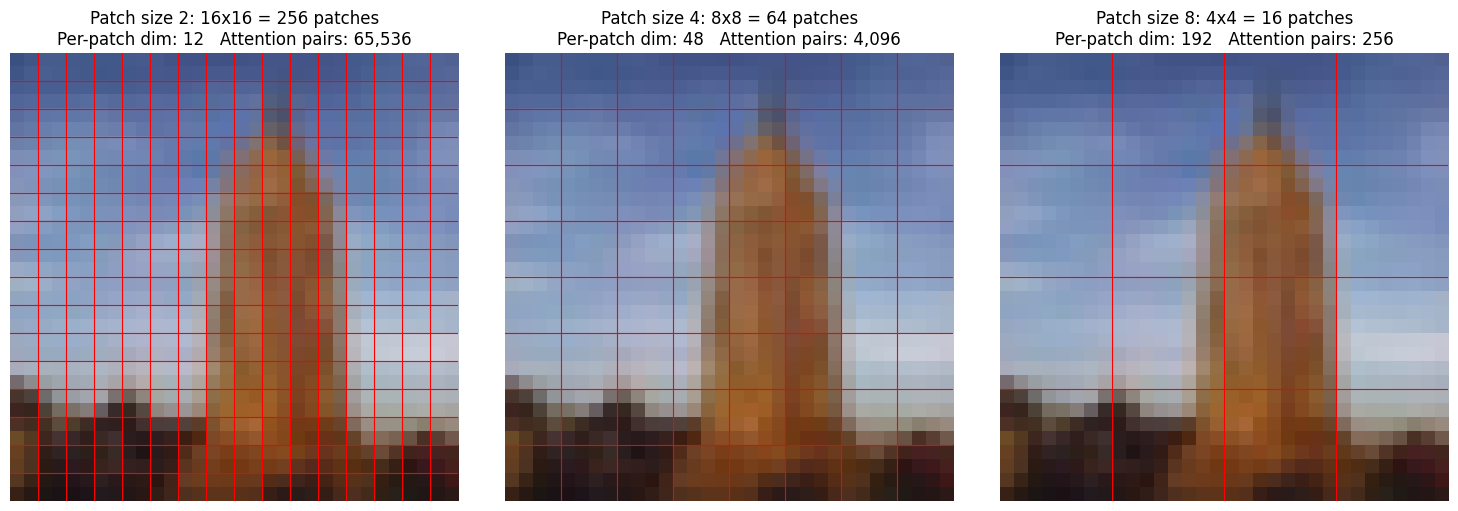

[3/3] PATCH SIZE TRADE-OFF ANALYSIS

Patch   Seq Len     Per-Patch Dim     Attn Pairs    Notes
---------------------------------------------------------------------------------------
2       256         12                65,536        Max detail, 16x attention cost
4       64          48                4,096         Chosen — balance
8       16          192               256           Low detail, too coarse

Decision: PATCH_SIZE = 4
    - 64-token sequence (manageable attention cost — 4,096 pairs per head)
    - 48-dim per patch (enough raw pixel content to carry local spatial info)
    - Standard for CIFAR-scale ViTs (DeiT, CCT, and original ViT CIFAR adaptations)
    - p=2 would quadruple sequence length (256 tokens, 65K attn pairs, ~16x cost)
    - p=8 would crush each patch to 16 tokens — insufficient for 32x32 detail

FINAL DATA / PATCH DECISIONS (EDA OUTPUT)
    Dataset:            CIFAR-100 (reuse from CNN #11)
    Image size:         32 x 32 x 3, normalized [0, 1]
    Train / Te

In [3]:
# Step 3: Patch Size Trade-off + Summary

# Show same image at 3 patch sizes to compare the trade-off visually
sample_idx = np.where(y_train_fine == sample_classes[0])[0][0]  # skyscraper from Cell 1
img = X_train[sample_idx]

PATCH_SIZES_TO_COMPARE = [2, 4, 8]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, p in zip(axes, PATCH_SIZES_TO_COMPARE):
    num_patches_per_side = 32 // p
    num_patches_total = num_patches_per_side ** 2
    per_patch_dim = p * p * 3
    attn_pairs = num_patches_total ** 2  # attention is quadratic in sequence length

    ax.imshow(img)
    for i in range(1, num_patches_per_side):
        ax.axhline(i * p - 0.5, color='red', linewidth=0.8)
        ax.axvline(i * p - 0.5, color='red', linewidth=0.8)
    ax.set_title(
        f"Patch size {p}: {num_patches_per_side}x{num_patches_per_side} = {num_patches_total} patches\n"
        f"Per-patch dim: {per_patch_dim}   Attention pairs: {attn_pairs:,}"
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

# Trade-off table
print("=" * 60)
print("[3/3] PATCH SIZE TRADE-OFF ANALYSIS")
print("=" * 60)

print(f"\n{'Patch':<8}{'Seq Len':<12}{'Per-Patch Dim':<18}{'Attn Pairs':<14}{'Notes'}")
print(f"{'-'*8}{'-'*12}{'-'*18}{'-'*14}{'-'*35}")
for p in PATCH_SIZES_TO_COMPARE:
    n = (32 // p) ** 2
    dim = p * p * 3
    pairs = n ** 2
    if p == 2:
        note = "Max detail, 16x attention cost"
    elif p == 4:
        note = "Chosen — balance"
    else:
        note = "Low detail, too coarse"
    print(f"{p:<8}{n:<12}{dim:<18}{pairs:<14,}{note}")

# Decision rationale
print(f"\nDecision: PATCH_SIZE = 4")
print(f"    - 64-token sequence (manageable attention cost — 4,096 pairs per head)")
print(f"    - 48-dim per patch (enough raw pixel content to carry local spatial info)")
print(f"    - Standard for CIFAR-scale ViTs (DeiT, CCT, and original ViT CIFAR adaptations)")
print(f"    - p=2 would quadruple sequence length (256 tokens, 65K attn pairs, ~16x cost)")
print(f"    - p=8 would crush each patch to 16 tokens — insufficient for 32x32 detail")

# Final data/patch decisions summary (feeds into pipeline constants)
print("\n" + "=" * 60)
print("FINAL DATA / PATCH DECISIONS (EDA OUTPUT)")
print("=" * 60)
print(f"    Dataset:            CIFAR-100 (reuse from CNN #11)")
print(f"    Image size:         32 x 32 x 3, normalized [0, 1]")
print(f"    Train / Test:       50,000 / 10,000, balanced 500/class")
print(f"    Classes:            100 fine / 20 coarse superclasses")
print(f"    Patch size:         4 x 4")
print(f"    Sequence length:    64 patches + 1 CLS token = 65 tokens")
print(f"    Baseline model:     ResNet-20 (CNN #11) — PT 80.1%, TF 79.5%")
print(f"    Comparison framing: Does ViT match/beat CNN on identical data?")